In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [66]:
df = pd.read_csv("customer_segmentation.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [67]:
df.shape

(2240, 29)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [69]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [72]:
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Missing Income values:", df["Income"].isnull().sum())

Missing Income values: 0


In [73]:
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_columns].sum(axis=1)

df[["ID", "Income", "Total_Spending"]].head()

,ID,Income,Total_Spending
0,5524,58138.0,1617
1,2174,46344.0,27
2,4141,71613.0,776
3,6182,26646.0,53
4,5324,58293.0,422


In [74]:
print("Python is working!")

Python is working!


In [75]:
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_columns].sum(axis=1)

df[["ID", "Total_Purchases"]].head()

,ID,Total_Purchases
0,5524,22
1,2174,4
2,4141,20
3,6182,6
4,5324,14


In [76]:
df["Age"] = 2014 - df["Year_Birth"]

df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,57
1,1954,60
2,1965,49
3,1984,30
4,1981,33


In [77]:
features = [
    "Income",
    "Age",
    "Kidhome",
    "Teenhome",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth"
]

X = df[features].copy()

X.head()

,Income,Age,Kidhome,Teenhome,Recency,Total_Spending,Total_Purchases,NumWebVisitsMonth
0,58138.0,57,0,0,58,1617,22,7
1,46344.0,60,1,1,38,27,4,5
2,71613.0,49,0,0,26,776,20,4
3,26646.0,30,1,0,26,53,6,6
4,58293.0,33,1,0,94,422,14,5


In [78]:
X.describe()

,Income,Age,Kidhome,Teenhome,Recency,Total_Spending,Total_Purchases,NumWebVisitsMonth
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,45.194196,0.444196,0.506250,49.109375,605.798214,12.537054,5.316518
std,25037.955891,11.984069,0.538398,0.544538,28.962453,602.249288,7.205741,2.426645
min,1730.000000,18.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,35538.750000,37.000000,0.000000,0.000000,24.000000,68.750000,6.000000,3.000000
50%,51381.500000,44.000000,0.000000,0.000000,49.000000,396.000000,12.000000,6.000000
75%,68289.750000,55.000000,1.000000,1.000000,74.000000,1045.500000,18.000000,7.000000
max,666666.000000,121.000000,2.000000,2.000000,99.000000,2525.000000,32.000000,20.000000


In [79]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)].copy()

print("Customers remaining:", len(df))

Customers remaining: 2237


In [80]:
X = df[features].copy()

print("Clustering data shape:", X.shape)

Clustering data shape: (2237, 8)


In [81]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")

Data standardized successfully!


In [82]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[12080.835063966726, 10277.848326344141, 9050.65660933432, 8383.609179351304, 7820.693285630992, 7484.4499449464665, 6840.585057248311, 6442.177047959236, 6284.212977942792]


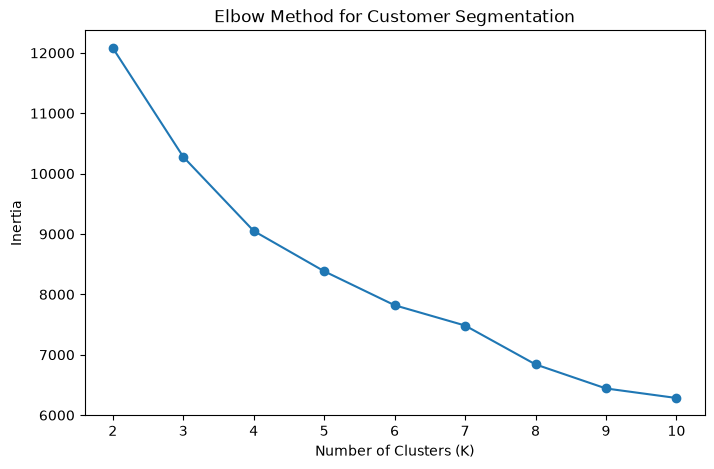

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")

plt.show()

In [84]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.299
K = 3: Silhouette Score = 0.253
K = 4: Silhouette Score = 0.233
K = 5: Silhouette Score = 0.228
K = 6: Silhouette Score = 0.227
K = 7: Silhouette Score = 0.219
K = 8: Silhouette Score = 0.203
K = 9: Silhouette Score = 0.205
K = 10: Silhouette Score = 0.195


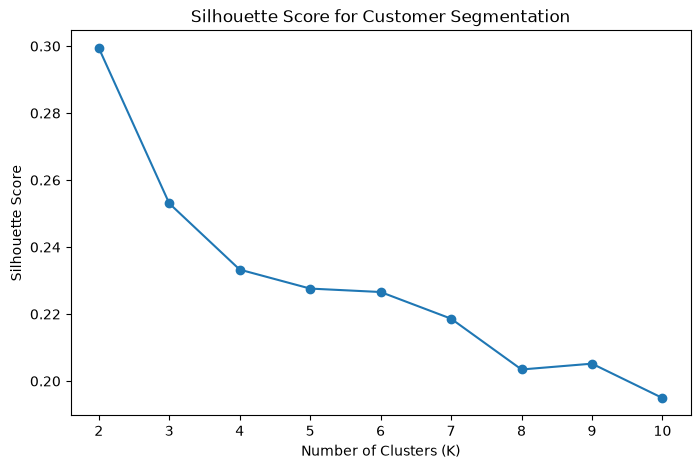

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Customer Segmentation")

plt.show()

In [86]:
best_k = 2

In [87]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["ID", "Income", "Total_Spending", "Total_Purchases", "Cluster"]].head(10)

,ID,Income,Total_Spending,Total_Purchases,Cluster
0,5524,58138.0,1617,22,0
1,2174,46344.0,27,4,3
2,4141,71613.0,776,20,0
3,6182,26646.0,53,6,1
4,5324,58293.0,422,14,1
5,7446,62513.0,716,20,2
6,965,55635.0,590,17,2
7,6177,33454.0,169,8,1
8,4855,30351.0,46,5,1
9,5899,5648.0,49,1,3


In [88]:
df["Cluster"].value_counts().sort_index()

Cluster
0    521
1    601
2    633
3    482
Name: count, dtype: int64

In [89]:
cluster_summary = df.groupby("Cluster")[[
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth"
]].mean().round(2)

cluster_summary

,Income,Age,Recency,Total_Spending,Total_Purchases,NumWebVisitsMonth
Cluster,,,,,,
0,77974.83,44.71,49.17,1375.63,19.11,2.65
1,30395.85,36.11,48.89,123.37,6.38,6.91
2,60063.72,50.96,50.02,782.40,17.31,5.20
3,41326.93,49.03,48.11,143.04,6.88,6.39


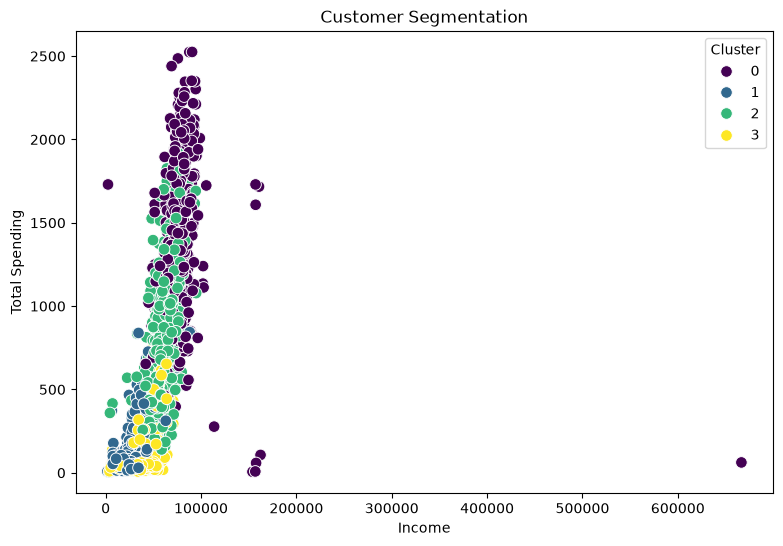

In [90]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

In [91]:
df.to_csv("customer_segmentation_with_clusters.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [92]:
df.to_csv("customer_segmentation_with_clusters.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [93]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["ID", "Income", "Total_Spending", "Total_Purchases", "Cluster"]].head(10)

,ID,Income,Total_Spending,Total_Purchases,Cluster
0,5524,58138.0,1617,22,0
1,2174,46344.0,27,4,3
2,4141,71613.0,776,20,0
3,6182,26646.0,53,6,1
4,5324,58293.0,422,14,1
5,7446,62513.0,716,20,2
6,965,55635.0,590,17,2
7,6177,33454.0,169,8,1
8,4855,30351.0,46,5,1
9,5899,5648.0,49,1,3


In [94]:
df["Cluster"].value_counts().sort_index()

Cluster
0    521
1    601
2    633
3    482
Name: count, dtype: int64

In [95]:
cluster_summary = df.groupby("Cluster")[[
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth"
]].mean().round(2)

cluster_summary

,Income,Age,Recency,Total_Spending,Total_Purchases,NumWebVisitsMonth
Cluster,,,,,,
0,77974.83,44.71,49.17,1375.63,19.11,2.65
1,30395.85,36.11,48.89,123.37,6.38,6.91
2,60063.72,50.96,50.02,782.40,17.31,5.20
3,41326.93,49.03,48.11,143.04,6.88,6.39


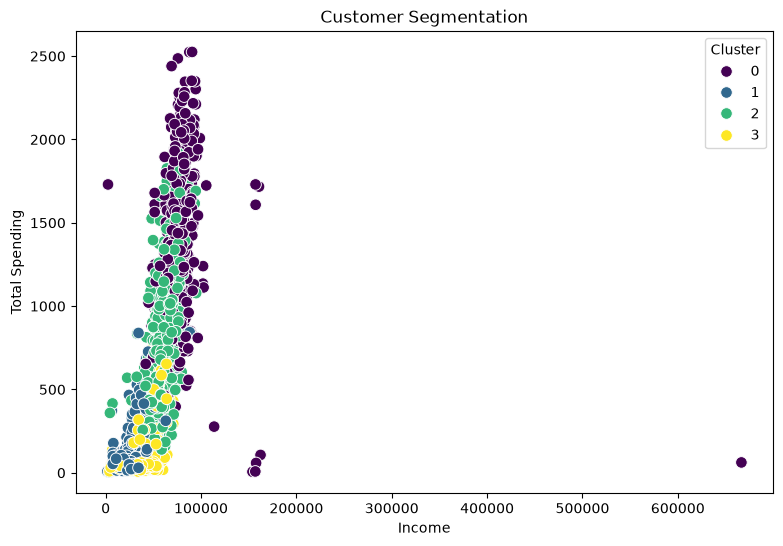

In [96]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.show()

In [97]:
cluster_summary = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean")
).round(2)

print(cluster_summary)

         Customers  Average_Income  Average_Spending
Cluster                                             
0              521        77974.83           1375.63
1              601        30395.85            123.37
2              633        60063.72            782.40
3              482        41326.93            143.04


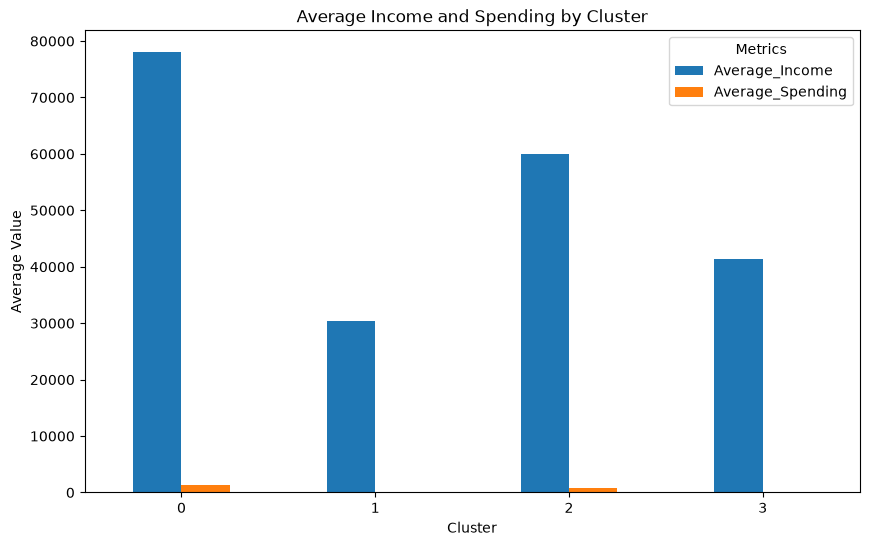

In [98]:
cluster_summary[[
    "Average_Income",
    "Average_Spending"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Income and Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.show()

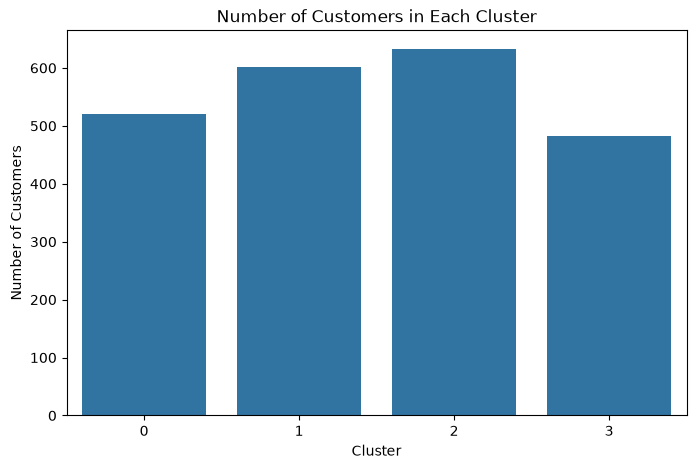

In [99]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [100]:
detailed_summary = df.groupby("Cluster").agg({
    "Income": ["mean", "median", "min", "max"],
    "Total_Spending": ["mean", "median", "min", "max"]
}).round(2)

print(detailed_summary)

           Income                            Total_Spending                  
             mean   median     min       max           mean  median min   max
Cluster                                                                      
0        77974.83  76542.0  2447.0  666666.0        1375.63  1366.0   6  2525
1        30395.85  30096.0  1730.0   88097.0         123.37    64.0   5   890
2        60063.72  60432.0  4428.0   94871.0         782.40   749.0  63  2092
3        41326.93  41612.0  4023.0   70844.0         143.04    71.5   8  1052


In [101]:
profile = df.groupby("Cluster")[[
    "Income",
    "Total_Spending"
]].mean().round(2)

profile

,Income,Total_Spending
Cluster,,
0,77974.83,1375.63
1,30395.85,123.37
2,60063.72,782.40
3,41326.93,143.04


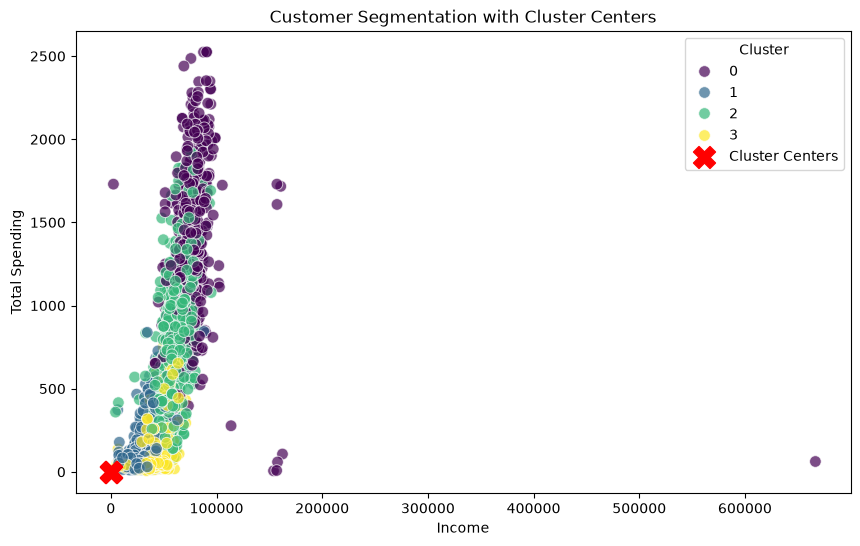

In [102]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="viridis",
    s=70,
    alpha=0.7
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Cluster Centers"
)

plt.title("Customer Segmentation with Cluster Centers")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.show()

In [103]:
print(df.nlargest(10, "Income")[[
    "Income",
    "Total_Spending",
    "Cluster"
]])

        Income  Total_Spending  Cluster
2233  666666.0              62        0
617   162397.0             107        0
687   160803.0            1717        0
1300  157733.0              59        0
164   157243.0            1608        0
1653  157146.0            1730        0
2132  156924.0               8        0
655   153924.0               6        0
1898  113734.0             277        0
646   105471.0            1724        0


In [104]:
print(df["Income"].describe())

count      2237.000000
mean      52227.407689
std       25043.266830
min        1730.000000
25%       35523.000000
50%       51381.500000
75%       68281.000000
max      666666.000000
Name: Income, dtype: float64


In [105]:
cluster_profile = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean")
).round(2)

print(cluster_profile)

         Customers  Average_Income  Average_Spending
Cluster                                             
0              521        77974.83           1375.63
1              601        30395.85            123.37
2              633        60063.72            782.40
3              482        41326.93            143.04


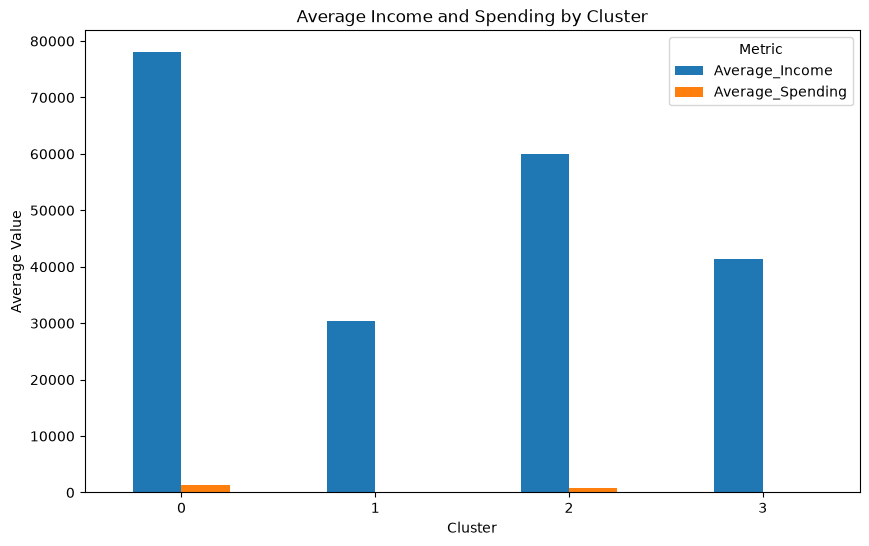

In [106]:
cluster_profile[[
    "Average_Income",
    "Average_Spending"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Income and Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()

In [107]:
from sklearn.metrics import silhouette_score

X = df[["Income", "Total_Spending"]]

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.594
K = 3, Silhouette Score = 0.598
K = 4, Silhouette Score = 0.544
K = 5, Silhouette Score = 0.525
K = 6, Silhouette Score = 0.535
K = 7, Silhouette Score = 0.542
K = 8, Silhouette Score = 0.518
K = 9, Silhouette Score = 0.516
K = 10, Silhouette Score = 0.520


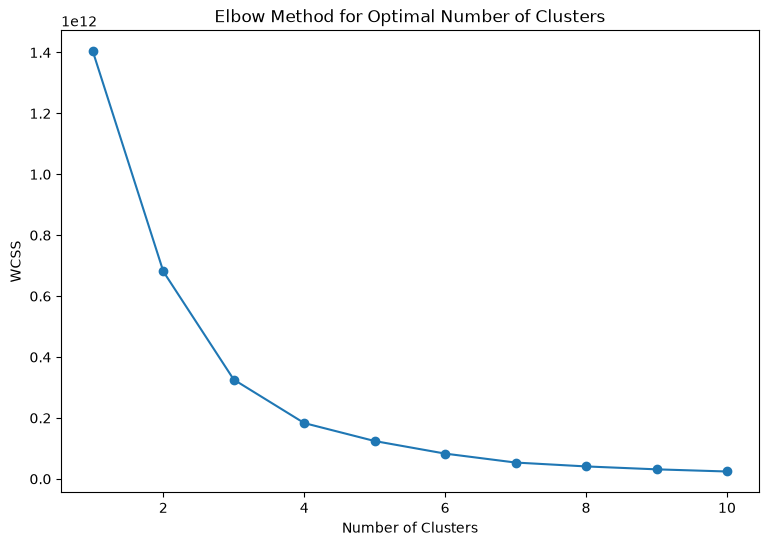

In [108]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [109]:
from sklearn.cluster import KMeans

X = df[["Income", "Total_Spending"]]

wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X)
    wcss.append(model.inertia_)

print(wcss)

[1403151323322.9028, 680900419072.0322, 325825748754.1559, 183178270431.3876, 124186592570.46379, 82914295773.59253, 53574960848.61459, 40851739516.62341, 31280155067.15097, 24196519868.477512]


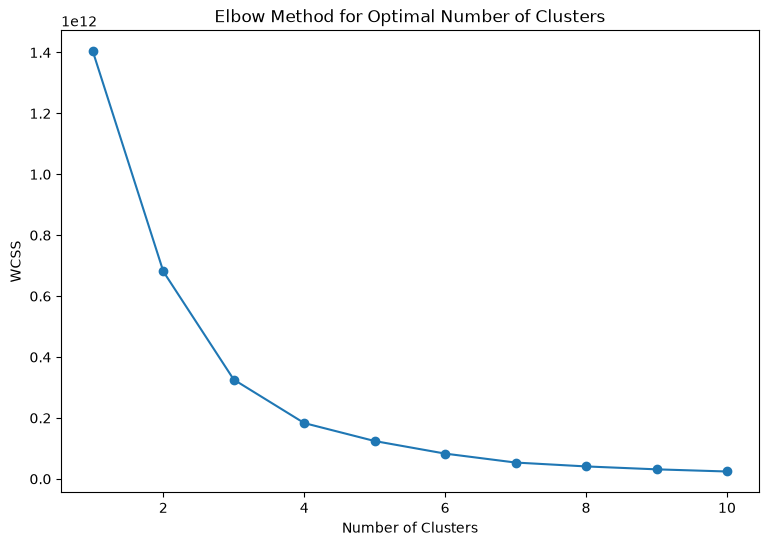

In [110]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [111]:
X = df[["Income", "Total_Spending"]]

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster_3"] = kmeans_3.fit_predict(X)

print("3-cluster model created successfully.")

3-cluster model created successfully.


In [112]:
profile_3 = df.groupby("Cluster_3").agg(
    Customers=("Cluster_3", "size"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean")
).round(2)

print(profile_3)

           Customers  Average_Income  Average_Spending
Cluster_3                                             
0               1070        70411.80           1076.69
1               1166        35013.22            174.04
2                  1       666666.00             62.00


In [113]:
profile_4 = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean")
).round(2)

print(profile_4)

         Customers  Average_Income  Average_Spending
Cluster                                             
0              521        77974.83           1375.63
1              601        30395.85            123.37
2              633        60063.72            782.40
3              482        41326.93            143.04


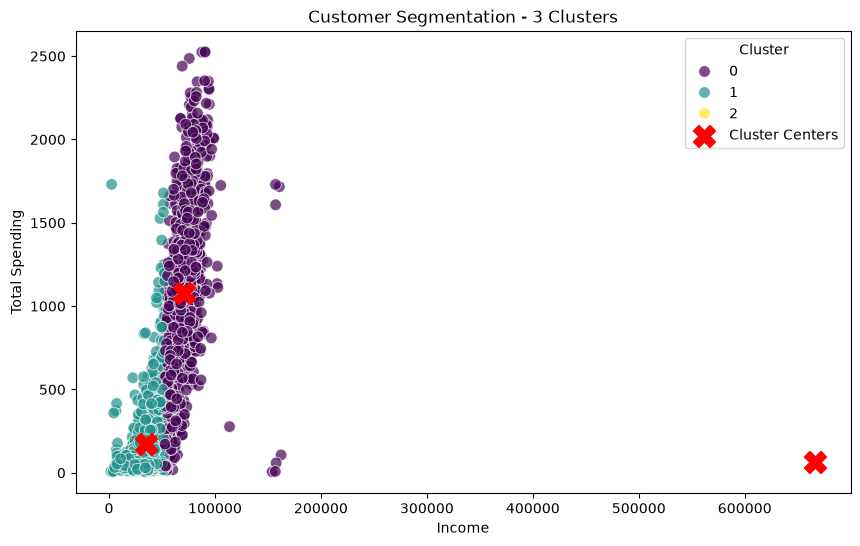

In [114]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster_3",
    palette="viridis",
    s=70,
    alpha=0.7
)

centers_3 = kmeans_3.cluster_centers_

plt.scatter(
    centers_3[:, 0],
    centers_3[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Cluster Centers"
)

plt.title("Customer Segmentation - 3 Clusters")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.show()

In [115]:
from sklearn.cluster import KMeans

X = df[["Income", "Total_Spending"]]

wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X)
    wcss.append(model.inertia_)

print(wcss)

[1403151323322.9028, 680900419072.0322, 325825748754.1559, 183178270431.3876, 124186592570.46379, 82914295773.59251, 53574960848.61458, 40851739516.62342, 31280155067.150963, 24196519868.477512]


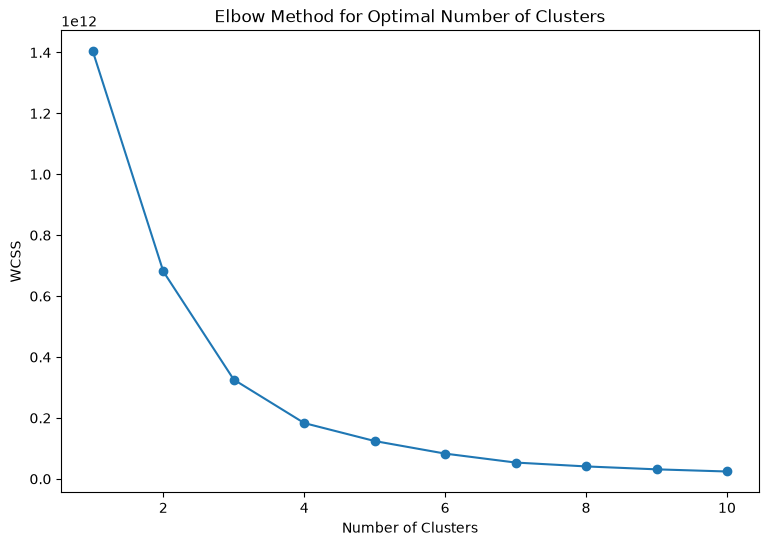

In [116]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [117]:
from sklearn.cluster import KMeans

X = df[["Income", "Total_Spending"]]

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster_3"] = kmeans_3.fit_predict(X)

print("3-cluster model created successfully.")

3-cluster model created successfully.


In [118]:
profile_3 = df.groupby("Cluster_3").agg(
    Customers=("Cluster_3", "size"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean")
).round(2)

print(profile_3)

           Customers  Average_Income  Average_Spending
Cluster_3                                             
0               1070        70411.80           1076.69
1               1166        35013.22            174.04
2                  1       666666.00             62.00


In [119]:
profile_4 = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean")
).round(2)

print(profile_4)

         Customers  Average_Income  Average_Spending
Cluster                                             
0              521        77974.83           1375.63
1              601        30395.85            123.37
2              633        60063.72            782.40
3              482        41326.93            143.04


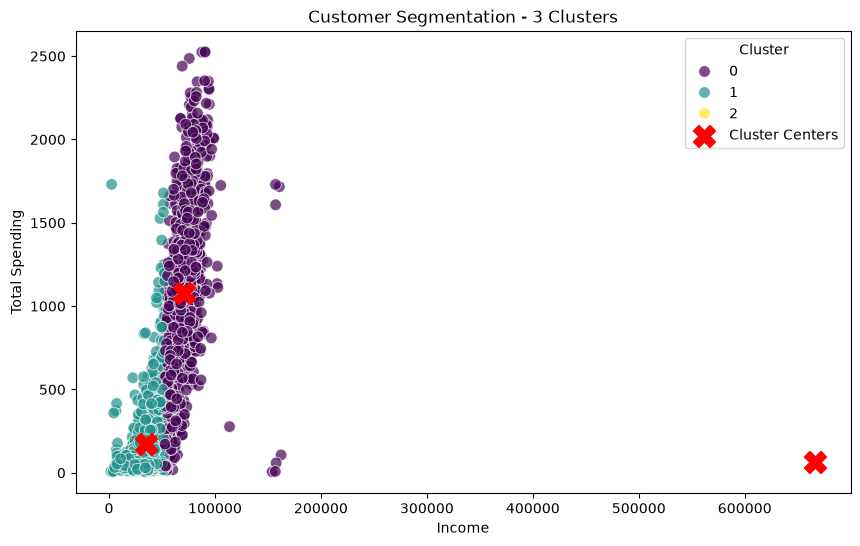

In [120]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster_3",
    palette="viridis",
    s=70,
    alpha=0.7
)

centers_3 = kmeans_3.cluster_centers_

plt.scatter(
    centers_3[:, 0],
    centers_3[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Cluster Centers"
)

plt.title("Customer Segmentation - 3 Clusters")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.show()

In [121]:
df[df["Income"] == df["Income"].max()][[
    "Income",
    "Total_Spending",
    "Cluster",
    "Cluster_3"
]]

,Income,Total_Spending,Cluster,Cluster_3
2233,666666.0,62,0,2


In [122]:
print("Maximum Income:", df["Income"].max())
print("Minimum Income:", df["Income"].min())
print("Number of customers:", len(df))

Maximum Income: 666666.0
Minimum Income: 1730.0
Number of customers: 2237


In [123]:
# Check for unusually high income values
print("Maximum Income:", df["Income"].max())
print("Minimum Income:", df["Income"].min())

print("\nCustomers with Income > 200000:")
display(df[df["Income"] > 200000][
    ["Income", "Total_Spending", "Cluster", "Cluster_3"]
])

Maximum Income: 666666.0
Minimum Income: 1730.0

Customers with Income > 200000:


,Income,Total_Spending,Cluster,Cluster_3
2233,666666.0,62,0,2


In [124]:
print("Maximum Spending:", df["Total_Spending"].max())
print("Minimum Spending:", df["Total_Spending"].min())

Maximum Spending: 2525
Minimum Spending: 5


In [125]:
# Inspect the outlier customer
display(
    df[df["Income"] == df["Income"].max()]
)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Total_Purchases,Age,Cluster,Cluster_3
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,0,0,3,11,0,62,7,37,0,2


In [126]:
# Check for missing values
print(df[["Income", "Total_Spending"]].isnull().sum())

Income            0
Total_Spending    0
dtype: int64


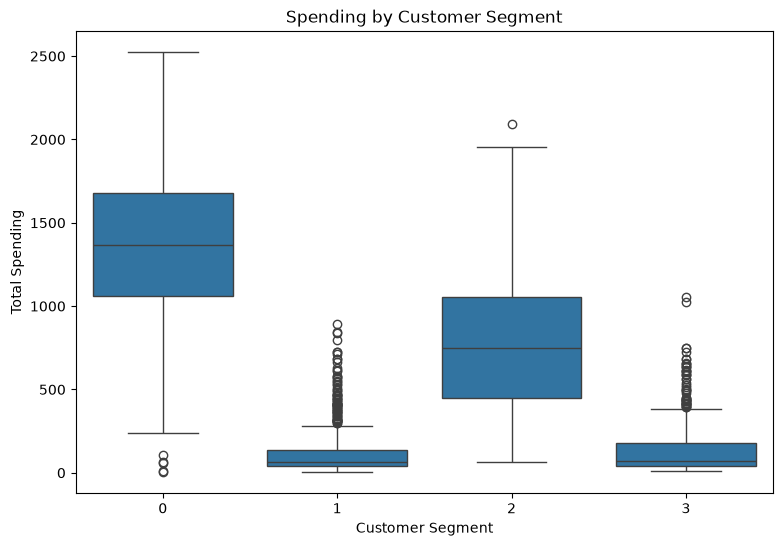

In [127]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Cluster",
    y="Total_Spending"
)

plt.title("Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Spending")

plt.show()

# Conclusion

Customer segmentation was performed using K-Means clustering based on Income and Total Spending.

The clustering analysis was evaluated using the Elbow Method and Silhouette Score. The results were used to examine the customer groups and their spending patterns.

The 3-cluster analysis showed clear differences in customer income and spending behavior. The analysis also identified one customer with an unusually high income of 666,666 and relatively low spending of 62. This observation was retained in the dataset and treated as an outlier rather than being removed automatically.

There were no missing values in the Income and Total_Spending variables.

Overall, the analysis demonstrates how K-Means clustering can be used to segment customers according to their income and spending characteristics.